# 01. Подробное знакомство с данными

Здесь познакомимся со всеми 48 колонками датасета Santander. Посмотрим, что означает каждое поле, какие в нём значения и пропуски и пригодится ли оно модели.

Отдельно разберём историю клиентов по месяцам и все 24 банковских продукта. Новой покупкой считаем переход `0→1`, а переход `1→0` — отключением. Если значение неизвестно, не будем считать его нулём.

Файл `train_ver2.csv` загружается целиком одним вызовом `pandas.read_csv`. Чтобы таблица занимала меньше памяти, используем компактные типы данных. Перед новым запуском лучше перезапустить ядро и освободить память.


In [1]:
from pathlib import Path
import gc
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    candidate = PROJECT_ROOT.parent
    if (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
    else:
        raise RuntimeError("Запустите ноутбук из корня проекта или каталога notebooks")

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from bank_recommender.constants import (
    CATEGORICAL_PROFILE_COLUMNS,
    DATE_COLUMN,
    ID_COLUMN,
    NUMERIC_PROFILE_COLUMNS,
    PRODUCT_COLUMNS,
    PRODUCT_DESCRIPTIONS_RU,
)

raw_data_path = Path(os.getenv("DATA_PATH", "train_ver2.csv")).expanduser()
DATA_PATH = raw_data_path if raw_data_path.is_absolute() else PROJECT_ROOT / raw_data_path
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Датасет не найден: {DATA_PATH}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Данные: {DATA_PATH}")


Корень проекта: C:\Users\nike1\projects\mle-pr-final
Данные: C:\Users\nike1\projects\mle-pr-final\train_ver2.csv


## 1. Загружаем все 48 колонок

Модель использует не все поля, но для знакомства с данными важно ничего не пропустить. Поэтому здесь оставляем и `fecha_alta`, и `ult_fec_cli_1t`, и `conyuemp`.

Продуктовые флаги сначала читаем как категории, проверяем их значения, а затем переводим в nullable `Int8`. Пропуски при этом не заполняем. Даты преобразуем после того, как сохраним исходную статистику качества.


In [2]:
SOURCE_DATE_COLUMNS = [DATE_COLUMN, "fecha_alta", "ult_fec_cli_1t"]
SOURCE_EXTRA_CATEGORICAL_COLUMNS = ["conyuemp"]
ALL_CATEGORICAL_COLUMNS = [
    *CATEGORICAL_PROFILE_COLUMNS,
    *SOURCE_EXTRA_CATEGORICAL_COLUMNS,
]

read_dtypes = {
    ID_COLUMN: "int32",
    **{column: "float32" for column in NUMERIC_PROFILE_COLUMNS},
    **{
        column: "category"
        for column in [*ALL_CATEGORICAL_COLUMNS, *SOURCE_DATE_COLUMNS]
    },
    **{column: "category" for column in PRODUCT_COLUMNS},
}

snapshots = pd.read_csv(
    DATA_PATH,
    dtype=read_dtypes,
    na_values=["NA", " NA", ""],
    skipinitialspace=True,
    low_memory=False,
)

source_row_count = len(snapshots)
source_column_order = snapshots.columns.tolist()
raw_non_null = snapshots.count()
raw_missing_count = source_row_count - raw_non_null
raw_indrel_1mes_distribution = snapshots["indrel_1mes"].value_counts(
    dropna=False
)
raw_product_invalid_counts = {}
for product in PRODUCT_COLUMNS:
    position = snapshots.columns.get_loc(product)
    values = snapshots.pop(product)
    categories = values.cat.categories.astype("string").str.strip()
    numeric_categories = pd.to_numeric(
        categories,
        errors="coerce",
    ).to_numpy(dtype=np.float64, na_value=np.nan)
    binary_categories = np.isin(numeric_categories, [0, 1])
    category_counts = values.value_counts(sort=False)
    raw_product_invalid_counts[product] = int(
        category_counts.reindex(
            values.cat.categories[~binary_categories],
            fill_value=0,
        ).sum()
    )

    old_codes = values.cat.codes.to_numpy()
    converted = np.zeros(len(values), dtype=np.int8)
    missing = old_codes < 0
    known_positions = np.flatnonzero(~missing)
    known_values = numeric_categories[old_codes[known_positions]]
    valid_known = np.isin(known_values, [0, 1])
    converted[known_positions[valid_known]] = known_values[valid_known].astype(
        np.int8
    )
    missing[known_positions[~valid_known]] = True
    snapshots.insert(
        position,
        product,
        pd.arrays.IntegerArray(converted, missing),
    )

raw_product_invalid = pd.Series(
    raw_product_invalid_counts,
    name="unexpected_values",
)

for column in SOURCE_DATE_COLUMNS:
    position = snapshots.columns.get_loc(column)
    values = snapshots.pop(column)
    parsed_categories = pd.to_datetime(
        values.cat.categories,
        errors="coerce",
    ).to_numpy()
    old_codes = values.cat.codes.to_numpy()
    parsed = np.full(len(values), np.datetime64("NaT"), dtype="datetime64[ns]")
    known = old_codes >= 0
    parsed[known] = parsed_categories[old_codes[known]]
    snapshots.insert(position, column, parsed)

for column in ALL_CATEGORICAL_COLUMNS:
    position = snapshots.columns.get_loc(column)
    values = snapshots.pop(column)
    categories = (
        pd.Series(values.cat.categories, dtype="string")
        .str.strip()
        .replace({"": pd.NA, "NA": pd.NA})
    )
    if column in {"cod_prov", "indrel_1mes"}:
        categories = categories.str.replace(r"\.0$", "", regex=True)

    canonical = pd.Categorical(categories)
    category_mapping = canonical.codes
    old_codes = values.cat.codes.to_numpy()
    new_codes = np.full(len(values), -1, dtype=np.int32)
    known = old_codes >= 0
    new_codes[known] = category_mapping[old_codes[known]]
    snapshots.insert(
        position,
        column,
        pd.Categorical.from_codes(
            new_codes,
            categories=canonical.categories,
        ),
    )

del (
    values,
    categories,
    old_codes,
    new_codes,
    known,
    converted,
    missing,
    known_positions,
    known_values,
    valid_known,
    numeric_categories,
    binary_categories,
    parsed,
    parsed_categories,
    canonical,
    category_mapping,
)

_ = gc.collect()


In [3]:
duplicate_customer_months = int(
    snapshots.duplicated([ID_COLUMN, DATE_COLUMN]).sum()
)
dataset_overview = pd.Series(
    {
        "строк": len(snapshots),
        "колонок": snapshots.shape[1],
        "уникальных клиентов": snapshots[ID_COLUMN].nunique(),
        "месячных снимков": snapshots[DATE_COLUMN].nunique(),
        "первая дата": snapshots[DATE_COLUMN].min().date(),
        "последняя дата": snapshots[DATE_COLUMN].max().date(),
        "дубликатов клиент-месяц": duplicate_customer_months,
        "память DataFrame, GiB": snapshots.memory_usage(deep=True).sum() / 1024**3,
        "размер CSV, GiB": DATA_PATH.stat().st_size / 1024**3,
    },
    name="значение",
)

display(dataset_overview.to_frame())
display(snapshots.head(3))


,значение
строк,13647309
колонок,48
уникальных клиентов,956645
месячных снимков,17
первая дата,2015-01-28
последняя дата,2016-05-28
дубликатов клиент-месяц,0
"память DataFrame, GiB",1.4998
"размер CSV, GiB",2.1353


,fecha_dato,ncodpers,ind_empleado,pais_residencia,sexo,age,fecha_alta,ind_nuevo,antiguedad,indrel,ult_fec_cli_1t,indrel_1mes,tiprel_1mes,indresi,indext,conyuemp,canal_entrada,indfall,tipodom,cod_prov,nomprov,ind_actividad_cliente,renta,segmento,ind_ahor_fin_ult1,ind_aval_fin_ult1,ind_cco_fin_ult1,ind_cder_fin_ult1,ind_cno_fin_ult1,ind_ctju_fin_ult1,ind_ctma_fin_ult1,ind_ctop_fin_ult1,ind_ctpp_fin_ult1,ind_deco_fin_ult1,ind_deme_fin_ult1,ind_dela_fin_ult1,ind_ecue_fin_ult1,ind_fond_fin_ult1,ind_hip_fin_ult1,ind_plan_fin_ult1,ind_pres_fin_ult1,ind_reca_fin_ult1,ind_tjcr_fin_ult1,ind_valo_fin_ult1,ind_viv_fin_ult1,ind_nomina_ult1,ind_nom_pens_ult1,ind_recibo_ult1
0,2015-01-28,1375586,N,ES,H,35.0000,2015-01-12,0.0000,6.0000,1.0000,NaT,1,A,S,N,<NA>,KHL,N,1.0000,29,MALAGA,1.0000,"87,218.1016",02 - PARTICULARES,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1050611,N,ES,V,23.0000,2012-08-10,0.0000,35.0000,1.0000,NaT,1,I,S,S,<NA>,KHE,N,1.0000,13,CIUDAD REAL,0.0000,"35,548.7383",03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1050612,N,ES,V,23.0000,2012-08-10,0.0000,35.0000,1.0000,NaT,1,I,S,N,<NA>,KHE,N,1.0000,13,CIUDAD REAL,0.0000,"122,179.1094",03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Составляем паспорт каждой колонки

Соберём простую памятку по колонкам: что является ключом, что описывает клиента, а что показывает наличие продукта. Рядом укажем, как поле будет использоваться дальше.

Затем добавим тип данных, число пропусков, количество уникальных значений и самое частое значение. Так мы быстро проверим каждую колонку.


In [4]:
PROFILE_DESCRIPTIONS = {
    DATE_COLUMN: "Дата месячного снимка",
    ID_COLUMN: "Идентификатор клиента",
    "ind_empleado": "Статус сотрудника банка",
    "pais_residencia": "Страна проживания",
    "sexo": "Пол",
    "age": "Возраст",
    "fecha_alta": "Дата первого договора с банком",
    "ind_nuevo": "Новый клиент за последние шесть месяцев",
    "antiguedad": "Стаж клиента в месяцах",
    "indrel": "Статус первичного клиента",
    "ult_fec_cli_1t": "Последняя дата статуса первичного клиента",
    "indrel_1mes": "Тип клиента в начале месяца",
    "tiprel_1mes": "Тип отношений с банком",
    "indresi": "Страна проживания совпадает со страной банка",
    "indext": "Клиент родился за пределами страны банка",
    "conyuemp": "Супруг или супруга сотрудника",
    "canal_entrada": "Канал привлечения",
    "indfall": "Признак смерти клиента",
    "tipodom": "Тип адреса",
    "cod_prov": "Код провинции",
    "nomprov": "Название провинции",
    "ind_actividad_cliente": "Признак активности клиента",
    "renta": "Доход домохозяйства",
    "segmento": "Клиентский сегмент",
}

COLUMN_ACTIONS = {
    DATE_COLUMN: "Преобразовать в дату; использовать год и месяц",
    ID_COLUMN: "Использовать как ключ, но не как признак модели",
    "ind_empleado": "Категория; редкие значения обрабатывает encoder",
    "pais_residencia": "Категория; редкие страны объединяет encoder",
    "sexo": "Категория с отдельным значением для пропуска",
    "age": "Проверить границы; пропуски заполнять только по train",
    "fecha_alta": "Проверить стаж; сырую дату не включать в текущую модель",
    "ind_nuevo": "Проверить домен и согласованность со стажем",
    "antiguedad": "Отрицательные служебные значения считать аномалиями",
    "indrel": "Категория 1/99, несмотря на числовое хранение",
    "ult_fec_cli_1t": "Оценить заполненность; не включать при почти полной пустоте",
    "indrel_1mes": "Унифицировать записи 1 и 1.0, 2 и 2.0",
    "tiprel_1mes": "Категориальный признак отношений с банком",
    "indresi": "Бинарная категория; сверить со страной",
    "indext": "Бинарная категория; сверить со страной",
    "conyuemp": "Оценить заполненность; исключить при почти полной пустоте",
    "canal_entrada": "Категория высокой мощности; объединять редкие значения",
    "indfall": "Редкий бизнес-флаг; контролировать отдельно",
    "tipodom": "Проверить на константность",
    "cod_prov": "Канонизировать как строковый код",
    "nomprov": "Сверить с кодом провинции и проверить дублирование",
    "ind_actividad_cliente": "Бинарный признак активности",
    "renta": "Логарифмировать; пропуски заполнять только по train",
    "segmento": "Категориальный клиентский сегмент",
}

catalog_rows = []
for column in source_column_order:
    if column in PRODUCT_COLUMNS:
        group = "продукт"
        description = PRODUCT_DESCRIPTIONS_RU[column]
        action = "Текущее владение — признак; переход 0→1 — целевая переменная"
    elif column in SOURCE_DATE_COLUMNS:
        group = "дата"
        description = PROFILE_DESCRIPTIONS[column]
        action = COLUMN_ACTIONS[column]
    elif column == ID_COLUMN:
        group = "ключ"
        description = PROFILE_DESCRIPTIONS[column]
        action = COLUMN_ACTIONS[column]
    else:
        group = "профиль клиента"
        description = PROFILE_DESCRIPTIONS[column]
        action = COLUMN_ACTIONS[column]
    catalog_rows.append(
        {
            "column": column,
            "group": group,
            "description": description,
            "decision": action,
        }
    )

column_catalog = pd.DataFrame(catalog_rows)
display(column_catalog)


,column,group,description,decision
0,fecha_dato,дата,Дата месячного снимка,Преобразовать в дату; использовать год и месяц
1,ncodpers,ключ,Идентификатор клиента,"Использовать как ключ, но не как признак модели"
2,ind_empleado,профиль клиента,Статус сотрудника банка,Категория; редкие значения обрабатывает encoder
3,pais_residencia,профиль клиента,Страна проживания,Категория; редкие страны объединяет encoder
4,sexo,профиль клиента,Пол,Категория с отдельным значением для пропуска
5,age,профиль клиента,Возраст,Проверить границы; пропуски заполнять только п...
6,fecha_alta,дата,Дата первого договора с банком,Проверить стаж; сырую дату не включать в текущ...
7,ind_nuevo,профиль клиента,Новый клиент за последние шесть месяцев,Проверить домен и согласованность со стажем
8,antiguedad,профиль клиента,Стаж клиента в месяцах,Отрицательные служебные значения считать анома...
9,indrel,профиль клиента,Статус первичного клиента,"Категория 1/99, несмотря на числовое хранение"


In [5]:
clean_non_null = snapshots.count()
clean_unique = snapshots.nunique(dropna=True)
top_values = {}
top_shares = {}
continuous_columns = {ID_COLUMN, "age", "antiguedad", "renta", "fecha_alta"}

for column in source_column_order:
    if column in continuous_columns:
        top_values[column] = pd.NA
        top_shares[column] = np.nan
        continue
    counts = snapshots[column].value_counts(dropna=False)
    if counts.empty:
        top_values[column] = pd.NA
        top_shares[column] = np.nan
        continue
    value = counts.index[0]
    top_values[column] = "<NA>" if pd.isna(value) else str(value)
    top_shares[column] = float(counts.iloc[0] / len(snapshots))

column_passport = (
    column_catalog.set_index("column")
    .assign(
        dtype=[str(snapshots[column].dtype) for column in column_catalog["column"]],
        raw_missing_count=raw_missing_count.reindex(column_catalog["column"]).to_numpy(),
        raw_missing_pct=(
            100
            * raw_missing_count.reindex(column_catalog["column"]).to_numpy()
            / len(snapshots)
        ),
        current_missing_count=(
            len(snapshots)
            - clean_non_null.reindex(column_catalog["column"]).to_numpy()
        ),
        unique_values=clean_unique.reindex(column_catalog["column"]).to_numpy(),
        top_value=[top_values[column] for column in column_catalog["column"]],
        top_share=[top_shares[column] for column in column_catalog["column"]],
    )
    .reset_index()
)

with pd.option_context("display.max_rows", len(column_passport)):
    display(column_passport)


,column,group,description,decision,dtype,raw_missing_count,raw_missing_pct,current_missing_count,unique_values,top_value,top_share
0,fecha_dato,дата,Дата месячного снимка,Преобразовать в дату; использовать год и месяц,datetime64[ns],0,0.0000,0,17,2016-05-28 00:00:00,0.0683
1,ncodpers,ключ,Идентификатор клиента,"Использовать как ключ, но не как признак модели",int32,0,0.0000,0,956645,<NA>,NaN
2,ind_empleado,профиль клиента,Статус сотрудника банка,Категория; редкие значения обрабатывает encoder,category,27734,0.2032,27734,5,N,0.9973
3,pais_residencia,профиль клиента,Страна проживания,Категория; редкие страны объединяет encoder,category,27734,0.2032,27734,118,ES,0.9931
4,sexo,профиль клиента,Пол,Категория с отдельным значением для пропуска,category,27804,0.2037,27804,2,V,0.5440
5,age,профиль клиента,Возраст,Проверить границы; пропуски заполнять только п...,float32,27734,0.2032,27734,120,<NA>,NaN
6,fecha_alta,дата,Дата первого договора с банком,Проверить стаж; сырую дату не включать в текущ...,datetime64[ns],27734,0.2032,27734,6756,<NA>,NaN
7,ind_nuevo,профиль клиента,Новый клиент за последние шесть месяцев,Проверить домен и согласованность со стажем,float32,27734,0.2032,27734,2,0.0,0.9385
8,antiguedad,профиль клиента,Стаж клиента в месяцах,Отрицательные служебные значения считать анома...,float32,27734,0.2032,27734,258,<NA>,NaN
9,indrel,профиль клиента,Статус первичного клиента,"Категория 1/99, несмотря на числовое хранение",float32,27734,0.2032,27734,2,1.0,0.9962


## 3. Проверяем временную ось и историю клиентов

Каждая строка показывает состояние клиента в конкретном месяце. Поэтому один `ncodpers` встречается несколько раз и не должен использоваться как числовой признак. Посчитаем отдельно строки по месяцам и число наблюдений на клиента.

Также проверим пропущенные месяцы: новую покупку можно определить только между соседними снимками.


In [6]:
monthly_coverage = (
    snapshots.groupby(DATE_COLUMN, observed=True)
    .agg(
        rows=(ID_COLUMN, "size"),
        customers=(ID_COLUMN, "nunique"),
    )
    .sort_index()
)
monthly_coverage["row_growth_pct"] = monthly_coverage["rows"].pct_change().mul(100)

customer_history = snapshots.groupby(ID_COLUMN, sort=False).agg(
    observations=(DATE_COLUMN, "nunique"),
    first_snapshot=(DATE_COLUMN, "min"),
    last_snapshot=(DATE_COLUMN, "max"),
)
first_month_number = (
    customer_history["first_snapshot"].dt.year * 12
    + customer_history["first_snapshot"].dt.month
)
last_month_number = (
    customer_history["last_snapshot"].dt.year * 12
    + customer_history["last_snapshot"].dt.month
)
customer_history["calendar_span"] = last_month_number - first_month_number + 1
customer_history["missing_months_inside_span"] = (
    customer_history["calendar_span"] - customer_history["observations"]
)

history_summary = customer_history[
    ["observations", "calendar_span", "missing_months_inside_span"]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T
history_checks = pd.Series(
    {
        "клиентов": len(customer_history),
        "клиентов с полной историей из 17 месяцев": int(
            customer_history["observations"].eq(17).sum()
        ),
        "клиентов с разрывом внутри наблюдаемого периода": int(
            customer_history["missing_months_inside_span"].gt(0).sum()
        ),
        "дубликатов клиент-месяц": duplicate_customer_months,
    },
    name="количество",
)

display(monthly_coverage)
display(history_summary)
display(history_checks.to_frame())


,rows,customers,row_growth_pct
fecha_dato,,,
2015-01-28,625457,625457,NaN
2015-02-28,627394,627394,0.3097
2015-03-28,629209,629209,0.2893
2015-04-28,630367,630367,0.1840
2015-05-28,631957,631957,0.2522
2015-06-28,632110,632110,0.0242
2015-07-28,829817,829817,31.2773
2015-08-28,843201,843201,1.6129
2015-09-28,865440,865440,2.6374


,count,mean,std,min,25%,50%,75%,90%,99%,max
observations,"956,645.0000",14.2658,4.0289,1.0000,11.0000,17.0000,17.0000,17.0000,17.0000,17.0000
calendar_span,"956,645.0000",14.2900,4.0287,1.0000,11.0000,17.0000,17.0000,17.0000,17.0000,17.0000
missing_months_inside_span,"956,645.0000",0.0242,0.3099,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000


,количество
клиентов,956645
клиентов с полной историей из 17 месяцев,605464
клиентов с разрывом внутри наблюдаемого периода,8018
дубликатов клиент-месяц,0


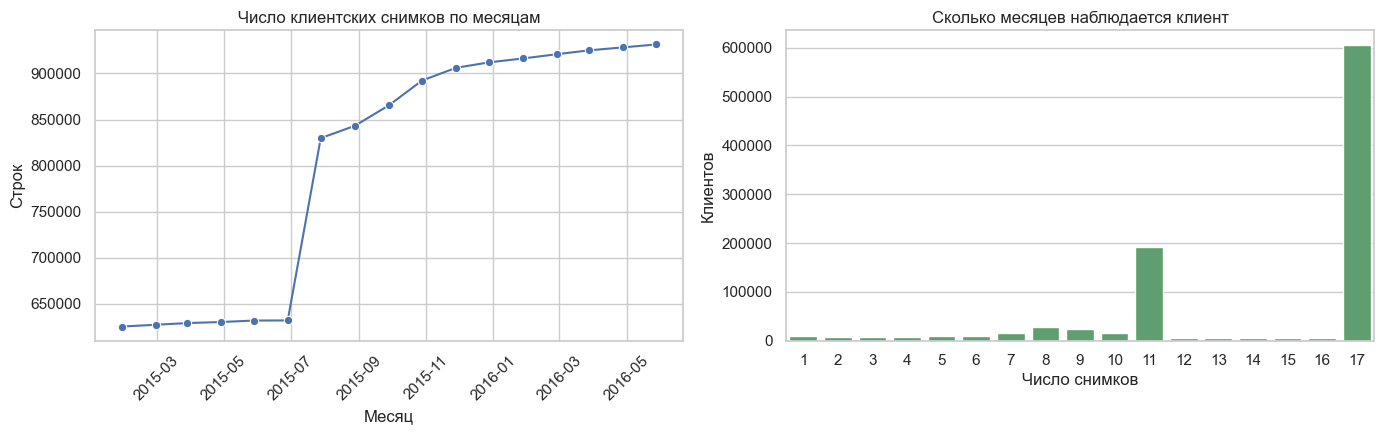

In [7]:
history_distribution = (
    customer_history["observations"].value_counts().sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.lineplot(
    data=monthly_coverage.reset_index(),
    x=DATE_COLUMN,
    y="rows",
    marker="o",
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("Число клиентских снимков по месяцам")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Строк")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    x=history_distribution.index,
    y=history_distribution.values,
    ax=axes[1],
    color="#55A868",
)
axes[1].set_title("Сколько месяцев наблюдается клиент")
axes[1].set_xlabel("Число снимков")
axes[1].set_ylabel("Клиентов")
plt.tight_layout()
plt.show()


## 4. Разбираем даты жизненного цикла

В данных есть три даты. `fecha_dato` — месяц снимка, `fecha_alta` — начало отношений с банком, а `ult_fec_cli_1t` встречается только у небольшой части клиентов.

Проверим диапазоны дат, странные случаи и связь с полем `antiguedad`. Когда нужен портрет клиента, берём только его последний снимок, чтобы один человек не учитывался много раз.


In [8]:
latest_indices = snapshots.groupby(ID_COLUMN, sort=False)[DATE_COLUMN].idxmax()
latest_clients = snapshots.loc[latest_indices]
final_snapshot_date = snapshots[DATE_COLUMN].max()
final_month_clients = snapshots.loc[
    snapshots[DATE_COLUMN].eq(final_snapshot_date)
]

date_rows = []
for column in SOURCE_DATE_COLUMNS:
    values = snapshots[column]
    date_rows.append(
        {
            "column": column,
            "non_null": int(values.notna().sum()),
            "missing_pct": float(values.isna().mean() * 100),
            "unique_dates": int(values.nunique()),
            "min": values.min(),
            "max": values.max(),
        }
    )
date_summary = pd.DataFrame(date_rows)

signup_after_snapshot = (
    snapshots["fecha_alta"].notna()
    & snapshots[DATE_COLUMN].notna()
    & snapshots["fecha_alta"].gt(snapshots[DATE_COLUMN])
)
premium_date_without_status_99 = (
    snapshots["ult_fec_cli_1t"].notna()
    & snapshots["indrel"].ne(99)
)

calculated_tenure = (
    (latest_clients[DATE_COLUMN].dt.year - latest_clients["fecha_alta"].dt.year) * 12
    + latest_clients[DATE_COLUMN].dt.month
    - latest_clients["fecha_alta"].dt.month
)
reported_tenure = latest_clients["antiguedad"]
tenure_comparison_mask = (
    calculated_tenure.notna()
    & reported_tenure.notna()
    & reported_tenure.ge(0)
)
tenure_difference = (
    reported_tenure[tenure_comparison_mask]
    - calculated_tenure[tenure_comparison_mask]
).abs()

date_checks = pd.Series(
    {
        "договоров позже соответствующего снимка": int(signup_after_snapshot.sum()),
        "дат окончания статуса при indrel != 99": int(
            premium_date_without_status_99.sum()
        ),
        "медианное расхождение стажа с fecha_alta, месяцев": float(
            tenure_difference.median()
        ),
        "доля расхождений стажа не более месяца": float(
            tenure_difference.le(1).mean()
        ),
    },
    name="значение",
)

display(date_summary)
display(date_checks.to_frame())


,column,non_null,missing_pct,unique_dates,min,max
0,fecha_dato,13647309,0.0000,17,2015-01-28,2016-05-28
1,fecha_alta,13619575,0.2032,6756,1995-01-16,2016-05-31
2,ult_fec_cli_1t,24793,99.8183,223,2015-07-01,2016-05-30


,значение
договоров позже соответствующего снимка,"11,586.0000"
дат окончания статуса при indrel != 99,0.0000
"медианное расхождение стажа с fecha_alta, месяцев",0.0000
доля расхождений стажа не более месяца,0.9349


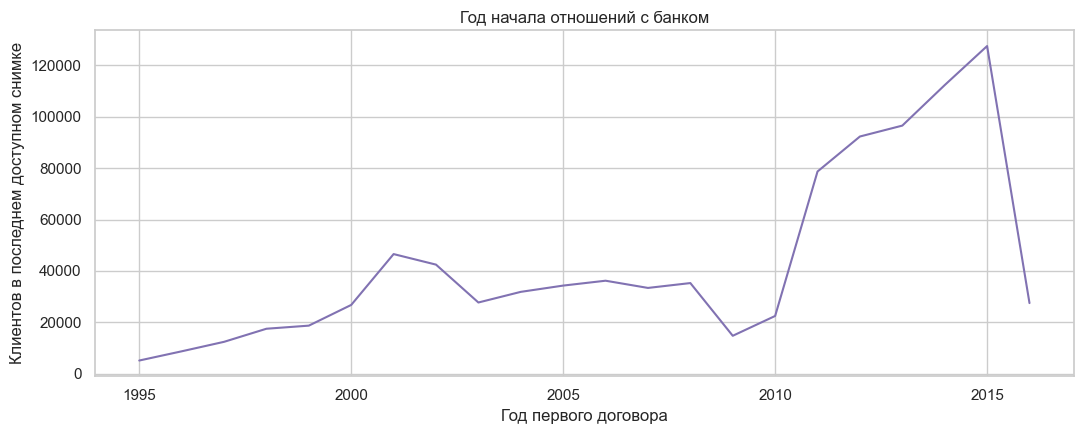

In [9]:
signup_years = (
    latest_clients["fecha_alta"]
    .dt.year.value_counts()
    .sort_index()
    .rename_axis("signup_year")
    .reset_index(name="customers")
)

plt.figure(figsize=(11, 4.5))
sns.lineplot(
    data=signup_years,
    x="signup_year",
    y="customers",
    color="#8172B2",
)
plt.title("Год начала отношений с банком")
plt.xlabel("Год первого договора")
plt.ylabel("Клиентов в последнем доступном снимке")
plt.tight_layout()
plt.show()


## 5. Проверяем числовые поля

Среднее значение может скрыть выбросы, поэтому для возраста, стажа и дохода посмотрим ещё квантили. Отдельно найдём слишком маленький или большой возраст, отрицательный стаж и очень высокий доход.

Числовые коды и флаги разберём отдельно в следующем разделе.


In [10]:
CONTINUOUS_COLUMNS = ["age", "antiguedad", "renta"]
numeric_summary = latest_clients[CONTINUOUS_COLUMNS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
).T

numeric_anomalies = pd.DataFrame(
    [
        {
            "column": "age",
            "missing": int(latest_clients["age"].isna().sum()),
            "below_expected": int(latest_clients["age"].lt(18).sum()),
            "above_expected": int(latest_clients["age"].gt(100).sum()),
            "rule": "ожидаемый диапазон 18–100 лет",
        },
        {
            "column": "antiguedad",
            "missing": int(latest_clients["antiguedad"].isna().sum()),
            "below_expected": int(latest_clients["antiguedad"].lt(0).sum()),
            "above_expected": int(latest_clients["antiguedad"].gt(300).sum()),
            "rule": "стаж не должен быть отрицательным",
        },
        {
            "column": "renta",
            "missing": int(latest_clients["renta"].isna().sum()),
            "below_expected": int(latest_clients["renta"].le(0).sum()),
            "above_expected": int(
                latest_clients["renta"].gt(
                    latest_clients["renta"].quantile(0.999)
                ).sum()
            ),
            "rule": "верхний хвост смотрим отдельно, но не удаляем автоматически",
        },
    ]
)

display(numeric_summary)
display(numeric_anomalies)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,99.9%,max
age,"949,614.0000",40.1541,17.1704,2.0000,20.0000,21.0000,25.0000,38.0000,50.0000,74.0000,89.0000,101.0000,164.0000
antiguedad,"949,614.0000",75.8231,"1,778.8190","-999,999.0000",0.0000,6.0000,22.0000,53.0000,133.0000,205.0000,238.0000,251.0000,256.0000
renta,"709,411.0000","134,096.4219","232,281.1875","1,202.7300","26,353.4395","40,029.5078","68,489.9375","101,489.3438","155,527.0625","309,957.8750","555,605.5625","1,554,932.0000","28,894,396.0000"


,column,missing,below_expected,above_expected,rule
0,age,7031,7490,992,ожидаемый диапазон 18–100 лет
1,antiguedad,7031,3,0,стаж не должен быть отрицательным
2,renta,247234,0,710,"верхний хвост смотрим отдельно, но не удаляем ..."


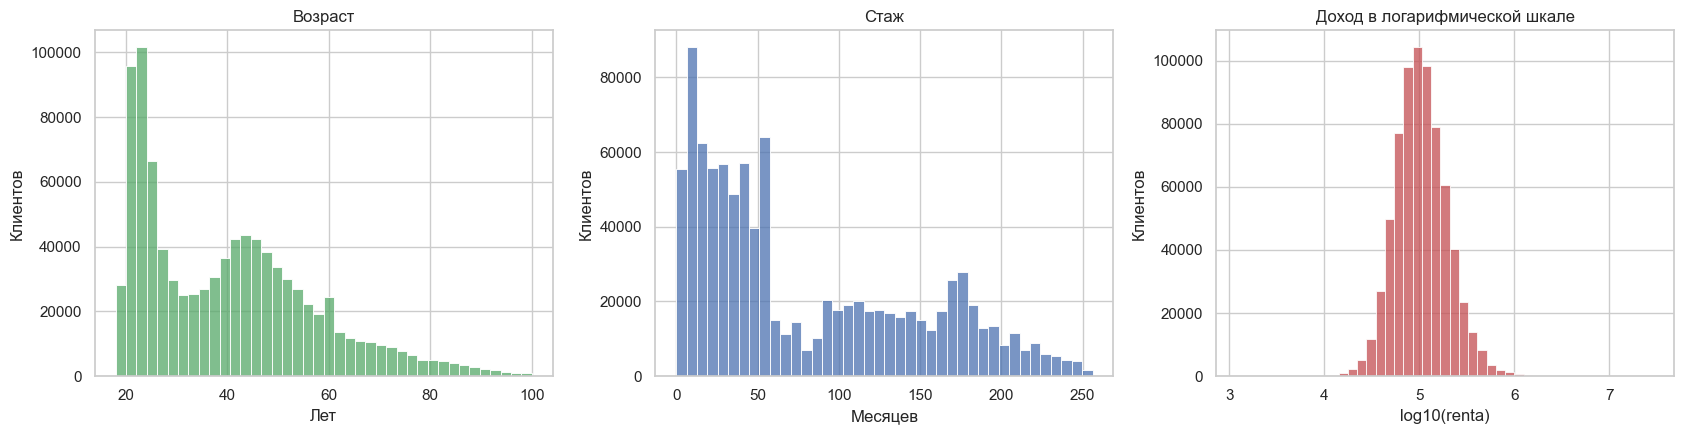

In [11]:
valid_age = latest_clients.loc[
    latest_clients["age"].between(18, 100), "age"
]
valid_tenure = latest_clients.loc[
    latest_clients["antiguedad"].between(0, 300), "antiguedad"
]
positive_income = latest_clients.loc[
    latest_clients["renta"].gt(0), "renta"
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(valid_age, bins=40, ax=axes[0], color="#55A868")
axes[0].set_title("Возраст")
axes[0].set_xlabel("Лет")

sns.histplot(valid_tenure, bins=40, ax=axes[1], color="#4C72B0")
axes[1].set_title("Стаж")
axes[1].set_xlabel("Месяцев")

sns.histplot(np.log10(positive_income), bins=45, ax=axes[2], color="#C44E52")
axes[2].set_title("Доход в логарифмической шкале")
axes[2].set_xlabel("log10(renta)")

for axis in axes:
    axis.set_ylabel("Клиентов")
plt.tight_layout()
plt.show()


## 6. Проверяем флаги и кодовые статусы

Некоторые поля записаны числами, но на самом деле это категории. Для них важнее посмотреть список значений, чем строить обычную гистограмму.

Заодно проверим связанные поля: совпадает ли признак нового клиента со стажем, страна — с резидентством, а код провинции — с названием. Значения `1` и `1.0` в `indrel_1mes` приведём к одному виду.


In [12]:
DOMAIN_EXPECTATIONS = {
    "ind_nuevo": {0, 1},
    "indrel": {1, 99},
    "tipodom": {1},
    "ind_actividad_cliente": {0, 1},
    "ind_empleado": {"A", "B", "F", "N", "S"},
    "sexo": {"H", "V"},
    "indrel_1mes": {"1", "2", "3", "4", "P"},
    "tiprel_1mes": {"A", "I", "P", "R"},
    "indresi": {"N", "S"},
    "indext": {"N", "S"},
    "conyuemp": {"N", "S"},
    "indfall": {"N", "S"},
    "segmento": {"01 - TOP", "02 - PARTICULARES", "03 - UNIVERSITARIO"},
}

domain_rows = []
for column, allowed in DOMAIN_EXPECTATIONS.items():
    values = snapshots[column]
    unexpected = values.notna() & ~values.isin(allowed)
    observed = values.value_counts(dropna=False)
    domain_rows.append(
        {
            "column": column,
            "allowed": ", ".join(map(str, sorted(allowed, key=str))),
            "observed_values": int(values.nunique(dropna=True)),
            "missing_count": int(values.isna().sum()),
            "unexpected_count": int(unexpected.sum()),
            "most_common": (
                "<NA>"
                if observed.empty or pd.isna(observed.index[0])
                else str(observed.index[0])
            ),
            "most_common_share": (
                np.nan if observed.empty else float(observed.iloc[0] / len(values))
            ),
        }
    )

domain_checks = pd.DataFrame(domain_rows)
display(domain_checks)


,column,allowed,observed_values,missing_count,unexpected_count,most_common,most_common_share
0,ind_nuevo,"0, 1",2,27734,0,0.0,0.9385
1,indrel,"1, 99",2,27734,0,1.0,0.9962
2,tipodom,1,1,27735,0,1.0,0.9980
3,ind_actividad_cliente,"0, 1",2,27734,0,0.0,0.5411
4,ind_empleado,"A, B, F, N, S",5,27734,0,N,0.9973
5,sexo,"H, V",2,27804,0,V,0.5440
6,indrel_1mes,"1, 2, 3, 4, P",5,149781,0,1,0.9885
7,tiprel_1mes,"A, I, P, R",5,149781,4,I,0.5353
8,indresi,"N, S",2,27734,0,S,0.9931
9,indext,"N, S",2,27734,0,N,0.9507


In [13]:
new_client_known = (
    snapshots["ind_nuevo"].notna()
    & snapshots["antiguedad"].notna()
    & snapshots["antiguedad"].ge(0)
)
new_client_mismatch = (
    new_client_known
    & snapshots["ind_nuevo"].eq(1)
    & snapshots["antiguedad"].gt(6)
)
existing_client_mismatch = (
    new_client_known
    & snapshots["ind_nuevo"].eq(0)
    & snapshots["antiguedad"].le(6)
)

residence_known = (
    snapshots["pais_residencia"].notna()
    & snapshots["indresi"].notna()
)
residence_mismatch = residence_known & (
    snapshots["pais_residencia"].eq("ES")
    != snapshots["indresi"].eq("S")
)

province_pairs = (
    latest_clients[["cod_prov", "nomprov"]]
    .dropna()
    .drop_duplicates()
)
province_names_per_code = province_pairs.groupby(
    "cod_prov", observed=True
)["nomprov"].nunique()
province_codes_per_name = province_pairs.groupby(
    "nomprov", observed=True
)["cod_prov"].nunique()

consistency_checks = pd.Series(
    {
        "новых клиентов со стажем больше 6 месяцев": int(
            new_client_mismatch.sum()
        ),
        "не новых клиентов со стажем не больше 6 месяцев": int(
            existing_client_mismatch.sum()
        ),
        "несогласованных pais_residencia и indresi": int(
            residence_mismatch.sum()
        ),
        "кодов провинций с несколькими названиями": int(
            province_names_per_code.gt(1).sum()
        ),
        "названий провинций с несколькими кодами": int(
            province_codes_per_name.gt(1).sum()
        ),
        "уникальных значений tipodom": int(
            snapshots["tipodom"].nunique(dropna=True)
        ),
    },
    name="количество",
)

indrel_normalisation = pd.concat(
    [
        raw_indrel_1mes_distribution.rename("до нормализации"),
        snapshots["indrel_1mes"]
        .value_counts(dropna=False)
        .rename("после нормализации"),
    ],
    axis=1,
).fillna(0)

display(consistency_checks.to_frame())
display(indrel_normalisation)


,количество
новых клиентов со стажем больше 6 месяцев,0
не новых клиентов со стажем не больше 6 месяцев,113096
несогласованных pais_residencia и indresi,5
кодов провинций с несколькими названиями,0
названий провинций с несколькими кодами,0
уникальных значений tipodom,1


,до нормализации,после нормализации
indrel_1mes,,
1.0,9133383,0.0000
1,4357298,"13,490,681.0000"
NaN,149781,"149,781.0000"
3.0,2780,0.0000
3,1570,"4,350.0000"
P,874,874.0000
2.0,740,0.0000
2,577,"1,317.0000"
4.0,223,0.0000


## 7. Разбираем все категориальные поля

Если значений мало, покажем их все. Для страны, канала и провинции выведем самые частые варианты. Распределения считаем по последнему снимку клиента, чтобы не учитывать одного человека несколько раз.

Особенно внимательно посмотрим на `canal_entrada`: в этом поле много редких значений, и часть из них может не попасть в обучающую выборку.


In [14]:
CATEGORY_ANALYSIS_COLUMNS = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "cod_prov",
    "nomprov",
    "segmento",
]

category_summary_rows = []
category_detail_rows = []
for column in CATEGORY_ANALYSIS_COLUMNS:
    values = latest_clients[column]
    counts = values.value_counts(dropna=False)
    counts = counts[counts > 0]
    non_missing_counts = values.value_counts(dropna=True)
    non_missing_counts = non_missing_counts[non_missing_counts > 0]
    rare_categories = int(
        (non_missing_counts / max(values.notna().sum(), 1) < 0.001).sum()
    )
    category_summary_rows.append(
        {
            "column": column,
            "unique_values": int(values.nunique(dropna=True)),
            "missing_count": int(values.isna().sum()),
            "missing_pct": float(values.isna().mean() * 100),
            "rare_categories_below_0_1_pct": rare_categories,
            "top_value": (
                "<NA>"
                if counts.empty or pd.isna(counts.index[0])
                else str(counts.index[0])
            ),
            "top_share": np.nan if counts.empty else float(counts.iloc[0] / len(values)),
        }
    )

    shown = counts if len(counts) <= 12 else counts.head(12)
    for value, count in shown.items():
        category_detail_rows.append(
            {
                "column": column,
                "value": "<NA>" if pd.isna(value) else str(value),
                "customers": int(count),
                "share": float(count / len(values)),
            }
        )
    if len(counts) > len(shown):
        other_count = int(counts.iloc[len(shown):].sum())
        category_detail_rows.append(
            {
                "column": column,
                "value": "<остальные>",
                "customers": other_count,
                "share": float(other_count / len(values)),
            }
        )

category_summary = pd.DataFrame(category_summary_rows)
category_details = pd.DataFrame(category_detail_rows)

display(category_summary)
with pd.option_context("display.max_rows", len(category_details)):
    display(category_details)


,column,unique_values,missing_count,missing_pct,rare_categories_below_0_1_pct,top_value,top_share
0,ind_empleado,5,7031,0.7350,4,N,0.9921
1,pais_residencia,118,7031,0.7350,117,ES,0.9885
2,sexo,2,7036,0.7355,0,V,0.5389
3,indrel_1mes,5,14686,1.5352,4,1,0.9836
4,tiprel_1mes,4,14686,1.5352,2,I,0.5655
5,indresi,2,7031,0.7350,0,S,0.9885
6,indext,2,7031,0.7350,0,N,0.9429
7,conyuemp,2,956524,99.9874,0,<NA>,0.9999
8,canal_entrada,162,18464,1.9301,125,KHE,0.2657
9,indfall,2,7031,0.7350,0,N,0.9898


,column,value,customers,share
0,ind_empleado,N,949094,0.9921
1,ind_empleado,<NA>,7031,0.0073
2,ind_empleado,B,219,0.0002
3,ind_empleado,F,152,0.0002
4,ind_empleado,A,148,0.0002
5,ind_empleado,S,1,0.0000
6,pais_residencia,ES,945596,0.9885
7,pais_residencia,<NA>,7031,0.0073
8,pais_residencia,FR,317,0.0003
9,pais_residencia,AR,289,0.0003


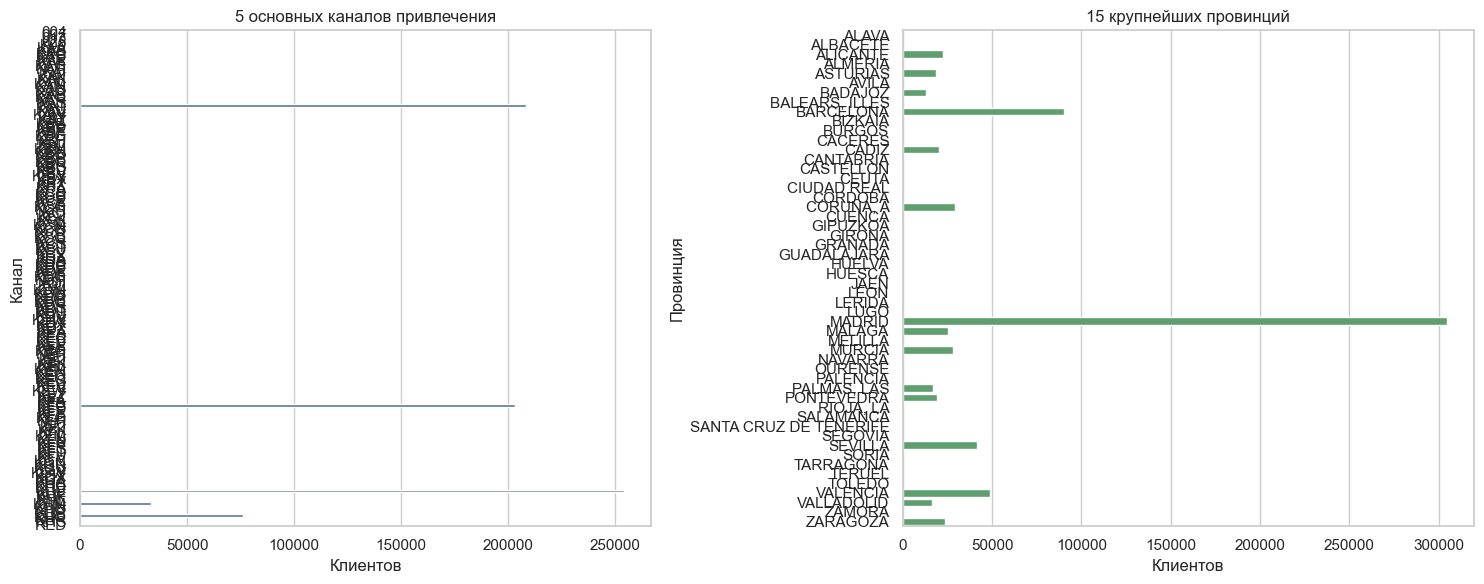

In [15]:
top_channels = (
    latest_clients["canal_entrada"]
    .value_counts()
    .head(5)
    .sort_values()
)
top_provinces = (
    latest_clients["nomprov"]
    .value_counts()
    .head(15)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    x=top_channels.values,
    y=top_channels.index,
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("5 основных каналов привлечения")
axes[0].set_xlabel("Клиентов")
axes[0].set_ylabel("Канал")

sns.barplot(
    x=top_provinces.values,
    y=top_provinces.index,
    ax=axes[1],
    color="#55A868",
)
axes[1].set_title("15 крупнейших провинций")
axes[1].set_xlabel("Клиентов")
axes[1].set_ylabel("Провинция")
plt.tight_layout()
plt.show()


## 8. Изучаем текущий портфель по всем 24 продуктам

Для каждого продукта проверим пропуски и неожиданные значения. Затем посчитаем, сколько раз продукт встречается по месяцам, сколько клиентов им когда-либо владели и сколько владельцев было в последнем месяце.

Важно не путать эти числа: сумма по всей таблице считает клиентские месяцы, а не уникальных владельцев. Поэтому покажем оба показателя отдельно.


In [16]:
snapshot_holdings = snapshots[PRODUCT_COLUMNS].sum(axis=0, skipna=True)
snapshot_non_null = snapshots[PRODUCT_COLUMNS].count()
snapshot_prevalence = snapshot_holdings / snapshot_non_null
ever_owned_by_customer = (
    snapshots.groupby(ID_COLUMN, sort=False)[PRODUCT_COLUMNS].max()
)
unique_customers_ever = ever_owned_by_customer.sum(axis=0, skipna=True)
del ever_owned_by_customer
final_month_holdings = final_month_clients[PRODUCT_COLUMNS].sum(
    axis=0,
    skipna=True,
)
final_month_non_null = final_month_clients[PRODUCT_COLUMNS].count()
final_month_prevalence = final_month_holdings / final_month_non_null

current_product_table = pd.DataFrame(
    {
        "product": PRODUCT_COLUMNS,
        "description": [PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
        "raw_missing_count": raw_missing_count.reindex(PRODUCT_COLUMNS).to_numpy(),
        "unexpected_values": raw_product_invalid.reindex(PRODUCT_COLUMNS).to_numpy(),
        "positive_customer_months": snapshot_holdings.reindex(PRODUCT_COLUMNS).to_numpy(),
        "snapshot_prevalence": snapshot_prevalence.reindex(PRODUCT_COLUMNS).to_numpy(),
        "unique_customers_ever": unique_customers_ever.reindex(PRODUCT_COLUMNS).to_numpy(),
        "final_month_owners": final_month_holdings.reindex(PRODUCT_COLUMNS).to_numpy(),
        "final_month_prevalence": final_month_prevalence.reindex(PRODUCT_COLUMNS).to_numpy(),
    }
).sort_values("final_month_prevalence", ascending=False, ignore_index=True)

with pd.option_context("display.max_rows", len(current_product_table)):
    display(current_product_table)


,product,description,raw_missing_count,unexpected_values,positive_customer_months,snapshot_prevalence,unique_customers_ever,final_month_owners,final_month_prevalence
0,ind_cco_fin_ult1,Текущий счёт,0,0,8945588,0.6555,622371,561615,0.6029
1,ind_recibo_ult1,Счёт прямого дебета,0,0,1745712,0.1279,157188,113050,0.1214
2,ind_ctop_fin_ult1,Особый счёт,0,0,1760616,0.1290,108104,100589,0.1080
3,ind_ecue_fin_ult1,Цифровой счёт,0,0,1129227,0.0827,81920,75845,0.0814
4,ind_cno_fin_ult1,Зарплатный проект,0,0,1103620,0.0809,85259,73061,0.0784
5,ind_nom_pens_ult1,Пенсионные обязательства,16063,0,810085,0.0594,75507,52848,0.0567
6,ind_nomina_ult1,Зарплатный счёт,16063,0,745961,0.0547,70356,48309,0.0519
7,ind_reca_fin_ult1,Налоговый счёт,0,0,716980,0.0525,47560,45535,0.0489
8,ind_tjcr_fin_ult1,Кредитная карта,0,0,605786,0.0444,58701,34822,0.0374
9,ind_ctpp_fin_ult1,Особый счёт 2,0,0,591008,0.0433,37160,33271,0.0357


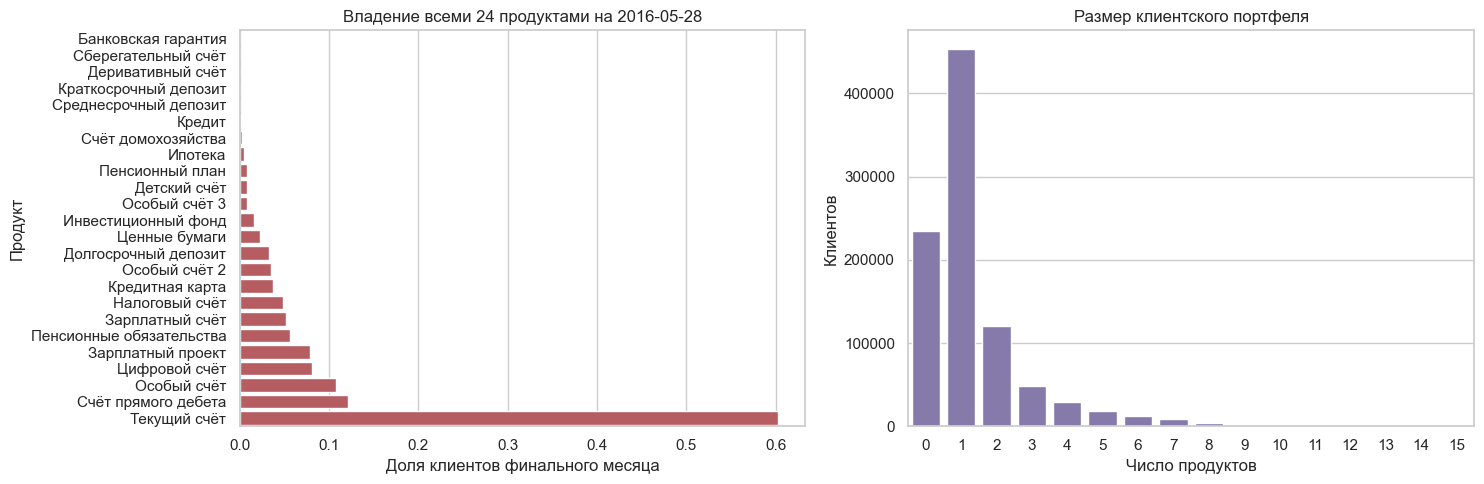

,значение
клиентов в финальном месяце,"931,453.0000"
клиентов со всеми известными продуктовыми флагами,"931,453.0000"
доля полностью известных портфелей,1.0000


,products_owned,customers,share
0,0,234914,0.2522
1,1,452986,0.4863
2,2,120532,0.1294
3,3,47813,0.0513
4,4,28767,0.0309
5,5,18046,0.0194
6,6,12689,0.0136
7,7,8356,0.0090
8,8,4445,0.0048
9,9,1897,0.0020


In [17]:
complete_product_mask = final_month_clients[PRODUCT_COLUMNS].notna().all(axis=1)
complete_product_clients = final_month_clients.loc[complete_product_mask]
final_month_product_count = (
    complete_product_clients[PRODUCT_COLUMNS]
    .sum(axis=1)
    .astype("int16")
)
portfolio_distribution = (
    final_month_product_count.value_counts()
    .sort_index()
    .rename_axis("products_owned")
    .reset_index(name="customers")
)
portfolio_distribution["share"] = (
    portfolio_distribution["customers"] / len(complete_product_clients)
)
portfolio_coverage = pd.Series(
    {
        "клиентов в финальном месяце": len(final_month_clients),
        "клиентов со всеми известными продуктовыми флагами": len(
            complete_product_clients
        ),
        "доля полностью известных портфелей": float(
            complete_product_mask.mean()
        ),
    },
    name="значение",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
product_plot = current_product_table.sort_values("final_month_prevalence")
sns.barplot(
    data=product_plot,
    x="final_month_prevalence",
    y="description",
    ax=axes[0],
    color="#C44E52",
)
axes[0].set_title(
    f"Владение всеми 24 продуктами на {final_snapshot_date:%Y-%m-%d}"
)
axes[0].set_xlabel("Доля клиентов финального месяца")
axes[0].set_ylabel("Продукт")

sns.barplot(
    data=portfolio_distribution,
    x="products_owned",
    y="customers",
    ax=axes[1],
    color="#8172B2",
)
axes[1].set_title("Размер клиентского портфеля")
axes[1].set_xlabel("Число продуктов")
axes[1].set_ylabel("Клиентов")
plt.tight_layout()
plt.show()

display(portfolio_coverage.to_frame())
display(portfolio_distribution)


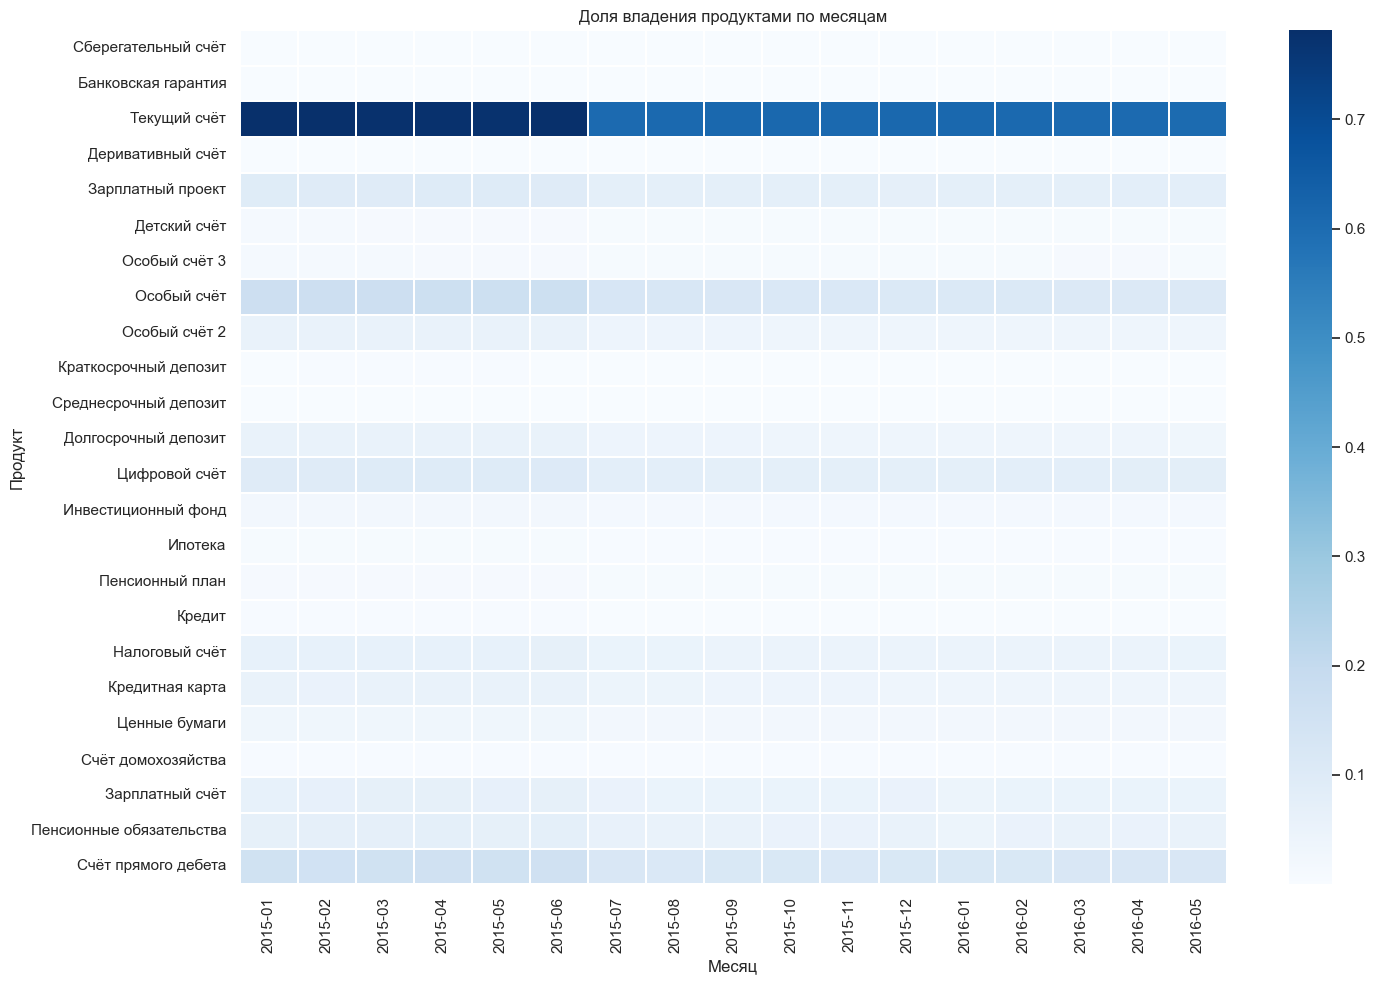

In [18]:
monthly_product_prevalence = (
    snapshots.groupby(DATE_COLUMN, observed=True)[PRODUCT_COLUMNS]
    .mean()
    .astype("float64")
    .T
)
monthly_product_prevalence.index = [
    PRODUCT_DESCRIPTIONS_RU[product] for product in monthly_product_prevalence.index
]
monthly_product_prevalence.columns = [
    date.strftime("%Y-%m") for date in monthly_product_prevalence.columns
]

plt.figure(figsize=(15, 10))
sns.heatmap(
    monthly_product_prevalence,
    cmap="Blues",
    linewidths=0.2,
)
plt.title("Доля владения продуктами по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Продукт")
plt.tight_layout()
plt.show()


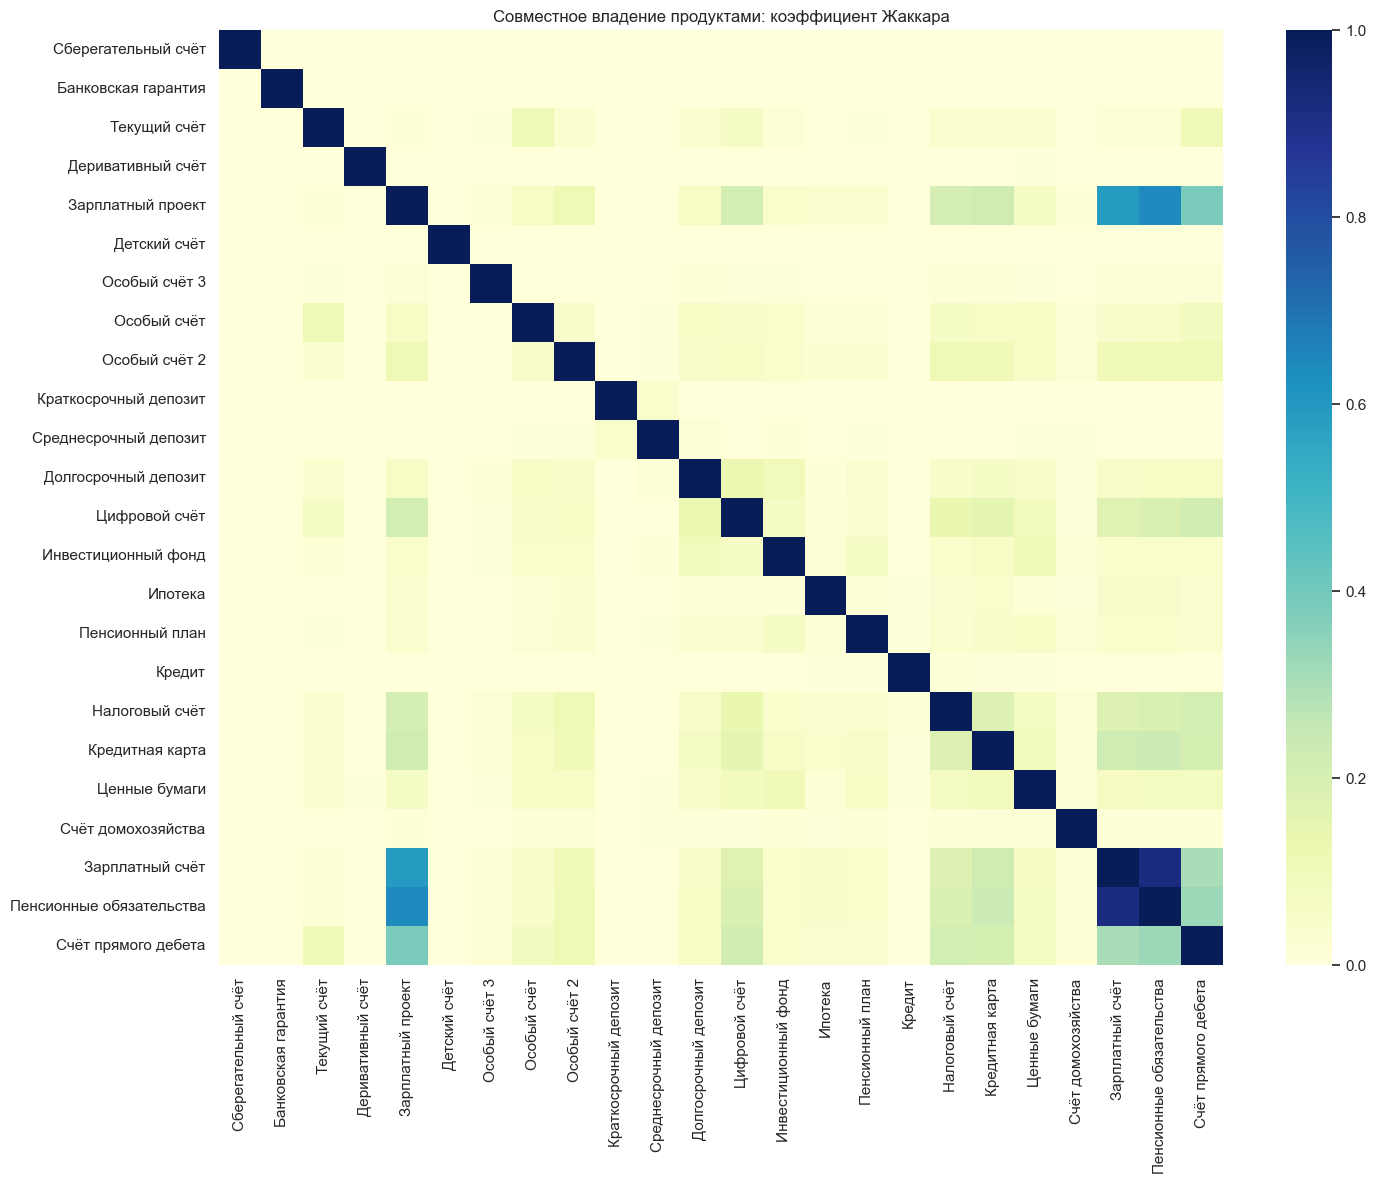

In [19]:
latest_owned_matrix = complete_product_clients[PRODUCT_COLUMNS].to_numpy(
    dtype=np.float32,
)
intersection = latest_owned_matrix.T @ latest_owned_matrix
owner_counts = np.diag(intersection)
union = owner_counts[:, None] + owner_counts[None, :] - intersection
jaccard = np.divide(
    intersection,
    union,
    out=np.zeros_like(intersection, dtype=np.float32),
    where=union > 0,
)
jaccard_frame = pd.DataFrame(
    jaccard,
    index=[PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
    columns=[PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
)

plt.figure(figsize=(15, 12))
sns.heatmap(jaccard_frame, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Совместное владение продуктами: коэффициент Жаккара")
plt.tight_layout()
plt.show()

del latest_owned_matrix, intersection, union
_ = gc.collect()


## 9. Считаем подключения и отключения продуктов

Чтобы сравнить соседние месяцы и не расходовать лишнюю память, берём только идентификатор клиента, месяц и продуктовые флаги.

Сравниваем только соседние месяцы одного клиента. Если значение продукта неизвестно хотя бы в одном месяце, не используем эту пару для данного продукта. Так пропуск не станет ложной покупкой.

В итоговой таблице отдельно покажем покупки в обучающей части и в проверке апрель→май 2016 года. Здесь оставляем только пары, где известны все 24 продуктовых флага. Такое же правило использует модель.


In [20]:
if duplicate_customer_months:
    raise ValueError("Сначала устраните дубликаты клиент-месяц")
if raw_product_invalid.sum():
    raise ValueError("В продуктовых колонках есть значения вне домена 0/1")

snapshot_ids = snapshots[ID_COLUMN].to_numpy(dtype=np.int32, copy=False)
snapshot_month_number = (
    snapshots[DATE_COLUMN].dt.year.to_numpy(dtype=np.int16) * 12
    + snapshots[DATE_COLUMN].dt.month.to_numpy(dtype=np.int16)
)
sort_order = np.lexsort((snapshot_month_number, snapshot_ids)).astype(
    np.int32,
    copy=False,
)
sorted_ids = snapshot_ids[sort_order]
sorted_months = snapshot_month_number[sort_order]
adjacent = (
    (sorted_ids[1:] == sorted_ids[:-1])
    & (sorted_months[1:] == sorted_months[:-1] + 1)
)
source_positions = sort_order[:-1][adjacent]
target_positions = sort_order[1:][adjacent]
target_month_numbers = sorted_months[1:][adjacent]
source_month_numbers = sorted_months[:-1][adjacent]

row_products_known = np.ones(len(snapshots), dtype=bool)
for product in PRODUCT_COLUMNS:
    row_products_known &= snapshots[product].notna().to_numpy()
fully_observed_pair = (
    row_products_known[source_positions]
    & row_products_known[target_positions]
)
validation_period = pd.Period("2016-04", freq="M")
validation_month_number = validation_period.year * 12 + validation_period.month
training_pair = fully_observed_pair & (
    source_month_numbers < validation_month_number
)
validation_pair = fully_observed_pair & (
    source_month_numbers == validation_month_number
)

first_target_month = int(target_month_numbers.min())
last_target_month = int(target_month_numbers.max())
month_axis = np.arange(first_target_month, last_target_month + 1)
month_codes = target_month_numbers - first_target_month
month_labels = [
    f"{(month_number - 1) // 12:04d}-{(month_number - 1) % 12 + 1:02d}"
    for month_number in month_axis
]

monthly_additions_matrix = np.zeros(
    (len(month_axis), len(PRODUCT_COLUMNS)),
    dtype=np.int64,
)
monthly_removals_matrix = np.zeros_like(monthly_additions_matrix)
monthly_valid_matrix = np.zeros_like(monthly_additions_matrix)
additions_per_pair = np.zeros(len(source_positions), dtype=np.uint8)
transition_rows = []

for product_index, product in enumerate(PRODUCT_COLUMNS):
    values = snapshots[product].to_numpy(dtype=np.int8, na_value=-1)
    before = values[source_positions]
    after = values[target_positions]
    valid = np.isin(before, [0, 1]) & np.isin(after, [0, 1])
    added = valid & (before == 0) & (after == 1)
    removed = valid & (before == 1) & (after == 0)

    valid_count = int(valid.sum())
    addition_count = int(added.sum())
    removal_count = int(removed.sum())
    additions_per_pair += added.astype(np.uint8)

    monthly_valid_matrix[:, product_index] = np.bincount(
        month_codes[valid],
        minlength=len(month_axis),
    )
    monthly_additions_matrix[:, product_index] = np.bincount(
        month_codes[added],
        minlength=len(month_axis),
    )
    monthly_removals_matrix[:, product_index] = np.bincount(
        month_codes[removed],
        minlength=len(month_axis),
    )

    transition_rows.append(
        {
            "product": product,
            "description": PRODUCT_DESCRIPTIONS_RU[product],
            "valid_pairs": valid_count,
            "addition_events": addition_count,
            "removal_events": removal_count,
            "model_train_additions": int((added & training_pair).sum()),
            "model_validation_additions": int(
                (added & validation_pair).sum()
            ),
            "additions_per_1000_valid_pairs": (
                1000 * addition_count / valid_count if valid_count else np.nan
            ),
            "removals_per_1000_valid_pairs": (
                1000 * removal_count / valid_count if valid_count else np.nan
            ),
            "months_with_additions": int(
                (monthly_additions_matrix[:, product_index] > 0).sum()
            ),
        }
    )

transition_table = pd.DataFrame(transition_rows).sort_values(
    "addition_events",
    ascending=False,
    ignore_index=True,
)
complete_additions_per_pair = additions_per_pair[fully_observed_pair]
pair_summary = pd.Series(
    {
        "соседних пар клиент-месяц": len(source_positions),
        "пар со всеми известными продуктовыми флагами": int(
            fully_observed_pair.sum()
        ),
        "событий 0→1 по всем допустимым продуктовым парам": int(
            additions_per_pair.sum()
        ),
        "событий 0→1 в полностью известных парах": int(
            complete_additions_per_pair.sum()
        ),
        "доля пар хотя бы с одним подключением": float(
            (complete_additions_per_pair > 0).mean()
        ),
        "среднее число подключений на полную пару": float(
            complete_additions_per_pair.mean()
        ),
        "максимум подключений в одной паре": int(
            complete_additions_per_pair.max()
        ),
        "всего событий 1→0": int(monthly_removals_matrix.sum()),
    },
    name="значение",
)

display(pair_summary.to_frame())
with pd.option_context("display.max_rows", len(transition_table)):
    display(transition_table)

del (
    snapshot_ids,
    snapshot_month_number,
    sort_order,
    sorted_ids,
    sorted_months,
    adjacent,
    target_positions,
    target_month_numbers,
    source_month_numbers,
    row_products_known,
    training_pair,
    validation_pair,
    values,
    before,
    after,
    valid,
    added,
    removed,
)
_ = gc.collect()


,значение
соседних пар клиент-месяц,"12,682,421.0000"
пар со всеми известными продуктовыми флагами,"12,669,584.0000"
событий 0→1 по всем допустимым продуктовым парам,"561,710.0000"
событий 0→1 в полностью известных парах,"561,648.0000"
доля пар хотя бы с одним подключением,0.0352
среднее число подключений на полную пару,0.0443
максимум подключений в одной паре,7.0000
всего событий 1→0,"533,164.0000"


,product,description,valid_pairs,addition_events,removal_events,model_train_additions,model_validation_additions,additions_per_1000_valid_pairs,removals_per_1000_valid_pairs,months_with_additions
0,ind_recibo_ult1,Счёт прямого дебета,12682421,153146,136273,142958,10163,12.0755,10.7450,16
1,ind_nom_pens_ult1,Пенсионные обязательства,12669584,84709,76035,79196,5513,6.6860,6.0014,16
2,ind_nomina_ult1,Зарплатный счёт,12669584,73753,65260,68265,5488,5.8213,5.1509,16
3,ind_tjcr_fin_ult1,Кредитная карта,12682421,69118,70340,64870,4248,5.4499,5.5463,16
4,ind_cco_fin_ult1,Текущий счёт,12682421,69103,89463,65223,3854,5.4487,7.0541,16
5,ind_cno_fin_ult1,Зарплатный проект,12682421,37098,23837,34752,2346,2.9252,1.8795,16
6,ind_ecue_fin_ult1,Цифровой счёт,12682421,26361,11003,23652,2709,2.0785,0.8676,16
7,ind_dela_fin_ult1,Долгосрочный депозит,12682421,12659,18515,12612,46,0.9982,1.4599,16
8,ind_reca_fin_ult1,Налоговый счёт,12682421,9234,11,8950,279,0.7281,0.0009,16
9,ind_ctma_fin_ult1,Особый счёт 3,12682421,6856,10018,6342,512,0.5406,0.7899,16


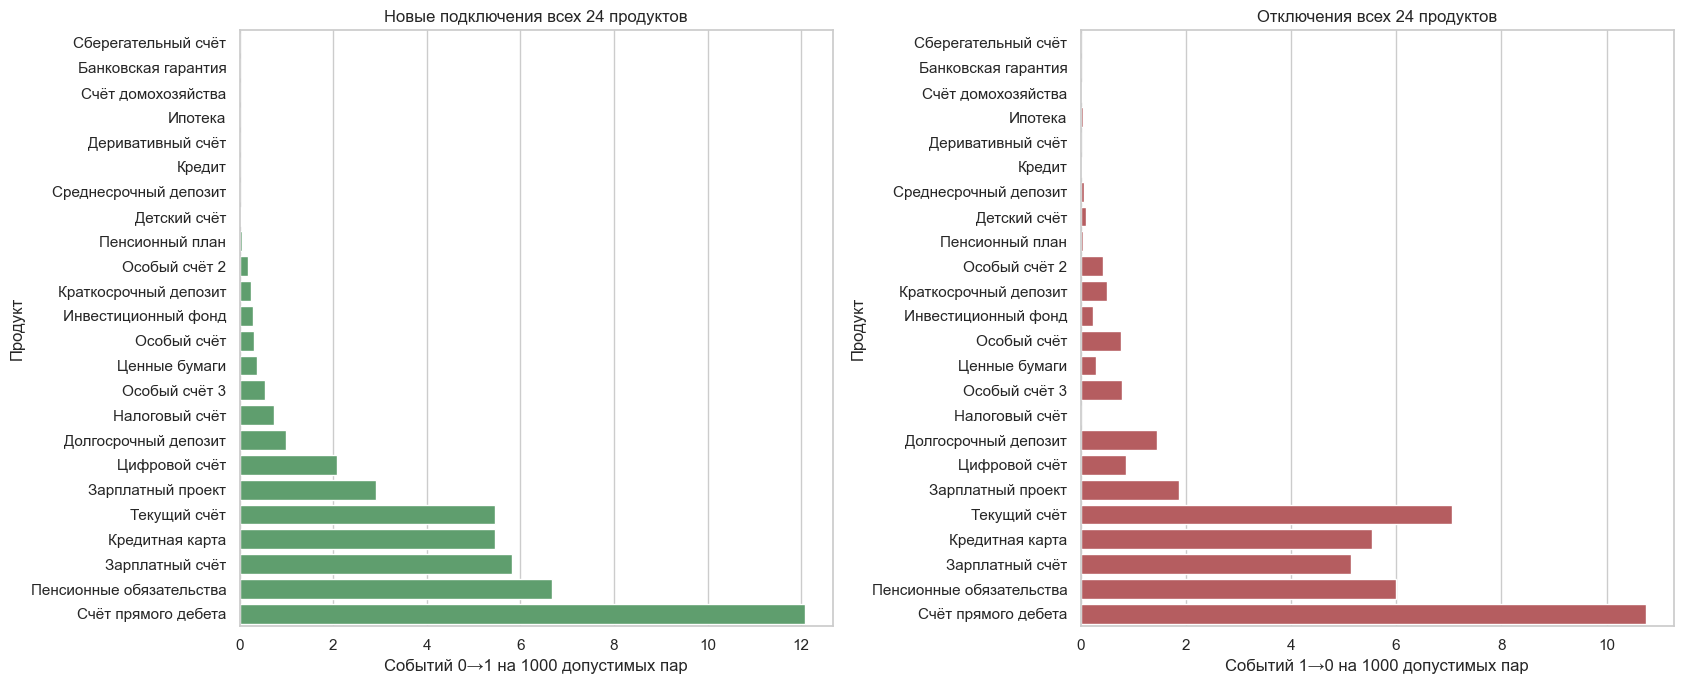

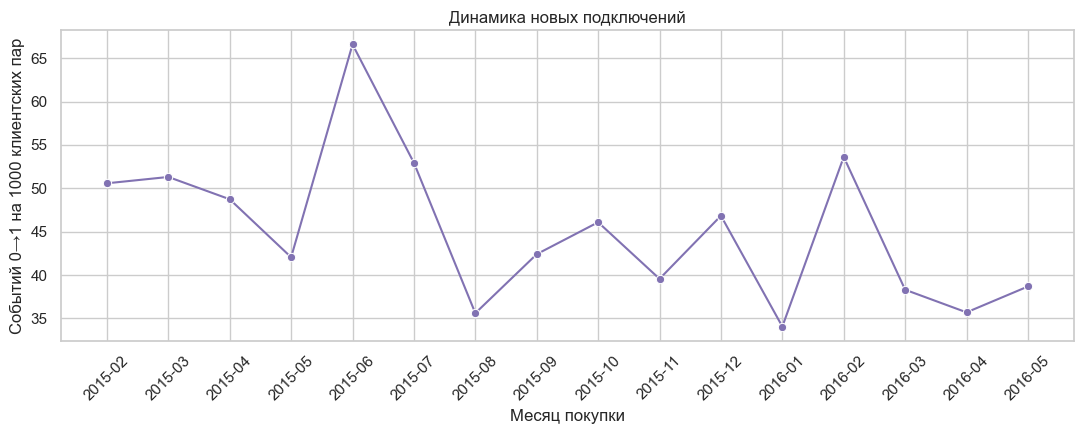

,target_month,adjacent_customer_pairs,fully_observed_pairs,addition_events,removal_events_by_product,additions_per_1000_pairs
0,2015-02,622926,620113,31364,32690,50.5779
1,2015-03,625094,622387,31934,30199,51.3089
2,2015-04,626698,623990,30410,28106,48.7348
3,2015-05,628135,625364,26296,35206,42.0491
4,2015-06,628603,626772,41737,31631,66.5904
5,2015-07,630249,630242,33362,30088,52.9352
6,2015-08,828361,828361,29490,36957,35.6004
7,2015-09,841795,841795,35696,30202,42.4046
8,2015-10,863690,863690,39803,31989,46.0848
9,2015-11,890170,890170,35215,34398,39.5599


In [21]:
transition_plot = transition_table.sort_values(
    "additions_per_1000_valid_pairs"
)
monthly_pair_count = np.bincount(
    month_codes,
    minlength=len(month_axis),
)
monthly_complete_pair_count = np.bincount(
    month_codes[fully_observed_pair],
    minlength=len(month_axis),
)
monthly_complete_additions = np.bincount(
    month_codes[fully_observed_pair],
    weights=complete_additions_per_pair,
    minlength=len(month_axis),
).astype(np.int64)
monthly_transition_summary = pd.DataFrame(
    {
        "target_month": month_labels,
        "adjacent_customer_pairs": monthly_pair_count,
        "fully_observed_pairs": monthly_complete_pair_count,
        "addition_events": monthly_complete_additions,
        "removal_events_by_product": monthly_removals_matrix.sum(axis=1),
    }
)
monthly_transition_summary["additions_per_1000_pairs"] = (
    1000
    * monthly_transition_summary["addition_events"]
    / monthly_transition_summary["fully_observed_pairs"]
)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.barplot(
    data=transition_plot,
    x="additions_per_1000_valid_pairs",
    y="description",
    ax=axes[0],
    color="#55A868",
)
axes[0].set_title("Новые подключения всех 24 продуктов")
axes[0].set_xlabel("Событий 0→1 на 1000 допустимых пар")
axes[0].set_ylabel("Продукт")

sns.barplot(
    data=transition_plot,
    x="removals_per_1000_valid_pairs",
    y="description",
    ax=axes[1],
    color="#C44E52",
)
axes[1].set_title("Отключения всех 24 продуктов")
axes[1].set_xlabel("Событий 1→0 на 1000 допустимых пар")
axes[1].set_ylabel("Продукт")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.5))
sns.lineplot(
    data=monthly_transition_summary,
    x="target_month",
    y="additions_per_1000_pairs",
    marker="o",
    color="#8172B2",
)
plt.title("Динамика новых подключений")
plt.xlabel("Месяц покупки")
plt.ylabel("Событий 0→1 на 1000 клиентских пар")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_transition_summary)


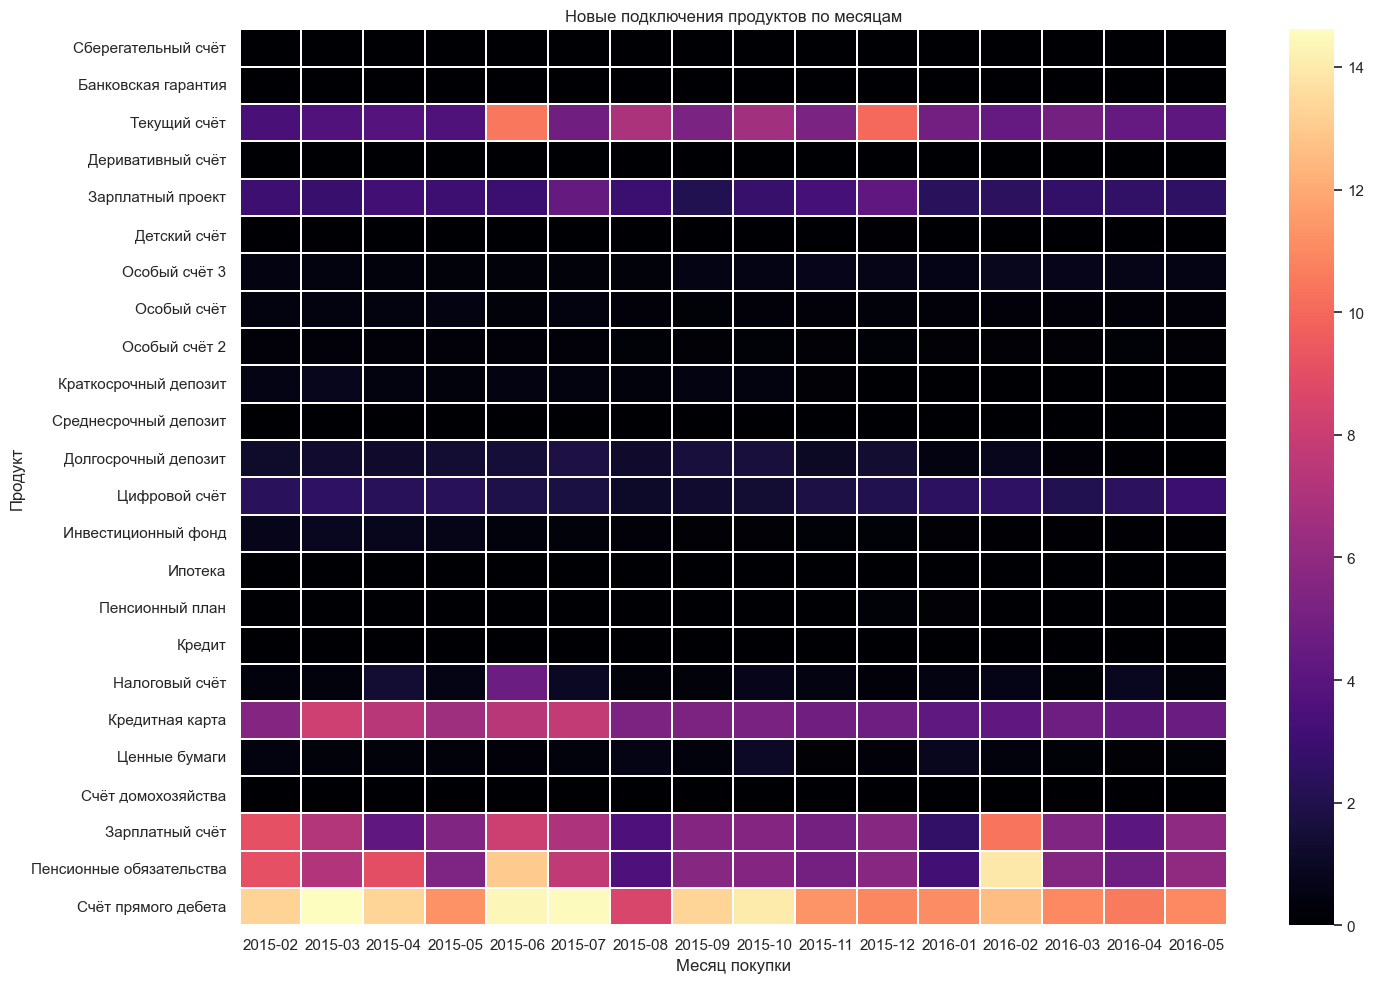

In [22]:
monthly_addition_rates = np.divide(
    1000 * monthly_additions_matrix,
    monthly_valid_matrix,
    out=np.zeros_like(monthly_additions_matrix, dtype=np.float64),
    where=monthly_valid_matrix > 0,
)
monthly_addition_rate_frame = pd.DataFrame(
    monthly_addition_rates.T,
    index=[PRODUCT_DESCRIPTIONS_RU[p] for p in PRODUCT_COLUMNS],
    columns=month_labels,
)

plt.figure(figsize=(15, 10))
sns.heatmap(
    monthly_addition_rate_frame,
    cmap="magma",
    linewidths=0.2,
)
plt.title("Новые подключения продуктов по месяцам")
plt.xlabel("Месяц покупки")
plt.ylabel("Продукт")
plt.tight_layout()
plt.show()


## 10. Связываем профиль клиента с будущей покупкой

Чтобы не строить много одинаковых графиков для редких продуктов, сначала ответим на простой вопрос: появился ли у клиента хотя бы один новый продукт в следующем месяце.

Сравним эту частоту по возрасту, стажу, доходу, полу, сегменту и активности. Рядом покажем размер группы: результат по нескольким клиентам нельзя считать таким же надёжным, как по большой группе.


In [23]:
analysis_source_positions = source_positions[fully_observed_pair]
has_any_addition = complete_additions_per_pair > 0

def target_rate_table(labels, feature):
    groups = pd.Series(labels).reset_index(drop=True)
    target = pd.Series(has_any_addition.astype(np.uint8))
    result = (
        target.groupby(groups, observed=True, dropna=False)
        .agg(pairs="size", pairs_with_addition="sum")
        .reset_index()
        .rename(columns={groups.name or "index": "group"})
    )
    if "group" not in result.columns:
        result = result.rename(columns={result.columns[0]: "group"})
    result.insert(0, "feature", feature)
    result["pairs_with_addition_per_1000"] = (
        1000 * result["pairs_with_addition"] / result["pairs"]
    )
    return result

age_values = snapshots["age"].to_numpy(dtype=np.float32)[analysis_source_positions]
tenure_values = snapshots["antiguedad"].to_numpy(dtype=np.float32)[analysis_source_positions]
income_values = snapshots["renta"].to_numpy(dtype=np.float32)[analysis_source_positions]

relationship_tables = [
    target_rate_table(
        pd.cut(
            age_values,
            bins=[0, 18, 25, 35, 45, 55, 65, 100, np.inf],
            right=False,
        ),
        "age_group",
    ),
    target_rate_table(
        pd.cut(
            tenure_values,
            bins=[-np.inf, 0, 6, 12, 36, 60, 120, 240, np.inf],
            right=False,
        ),
        "tenure_group",
    ),
    target_rate_table(
        pd.cut(
            income_values,
            bins=[-np.inf, 0, 50_000, 100_000, 150_000, 300_000, 1_000_000, np.inf],
            right=False,
        ),
        "income_group",
    ),
]

for column in [
    "sexo",
    "segmento",
    "ind_actividad_cliente",
    "tiprel_1mes",
    "canal_entrada",
    "nomprov",
]:
    labels = snapshots[column].iloc[analysis_source_positions].reset_index(drop=True)
    table = target_rate_table(labels, column)
    if column in {"canal_entrada", "nomprov"}:
        table = table.nlargest(15, "pairs")
    relationship_tables.append(table)

target_relationships = pd.concat(relationship_tables, ignore_index=True)
target_relationships = target_relationships.sort_values(
    ["feature", "pairs"],
    ascending=[True, False],
)

with pd.option_context("display.max_rows", len(target_relationships)):
    display(target_relationships)

del age_values, tenure_values, income_values
_ = gc.collect()


,feature,group,pairs,pairs_with_addition,pairs_with_addition_per_1000
1,age_group,"[18.0, 25.0)",3155392,47407,15.0241
3,age_group,"[35.0, 45.0)",2468633,129716,52.5457
4,age_group,"[45.0, 55.0)",2305123,107996,46.8504
2,age_group,"[25.0, 35.0)",2228897,82523,37.0241
6,age_group,"[65.0, 100.0)",1237668,34107,27.5575
5,age_group,"[55.0, 65.0)",1140216,43693,38.3199
0,age_group,"[0.0, 18.0)",111249,507,4.5573
7,age_group,"[100.0, inf)",14666,50,3.4092
8,age_group,NaN,7740,453,58.5271
41,canal_entrada,KHE,3799326,42547,11.1986


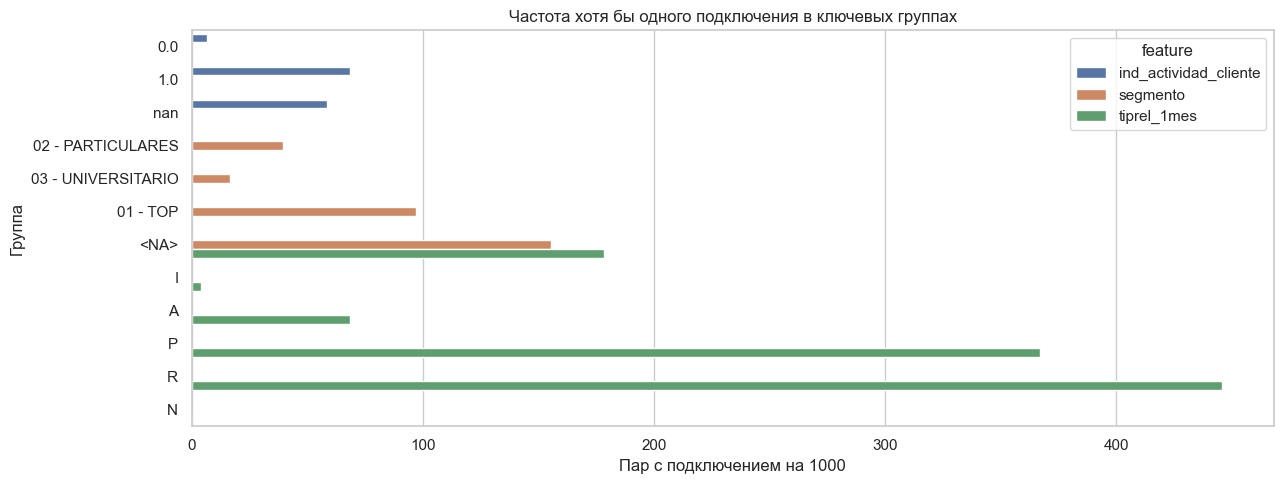

In [24]:
segment_activity_plot = target_relationships[
    target_relationships["feature"].isin(
        ["segmento", "ind_actividad_cliente", "tiprel_1mes"]
    )
].copy()
segment_activity_plot["group"] = segment_activity_plot["group"].astype(str)

plt.figure(figsize=(13, 5))
sns.barplot(
    data=segment_activity_plot,
    x="pairs_with_addition_per_1000",
    y="group",
    hue="feature",
)
plt.title("Частота хотя бы одного подключения в ключевых группах")
plt.xlabel("Пар с подключением на 1000")
plt.ylabel("Группа")
plt.tight_layout()
plt.show()


## 11. Смотрим, меняется ли качество данных со временем

Со временем могут меняться не только покупки, но и сами данные: состав клиентов и число пропусков.

Посмотрим, как меняется доля пропусков по месяцам. Если она резко сдвигается, качество модели тоже стоит проверять отдельно для каждого периода.


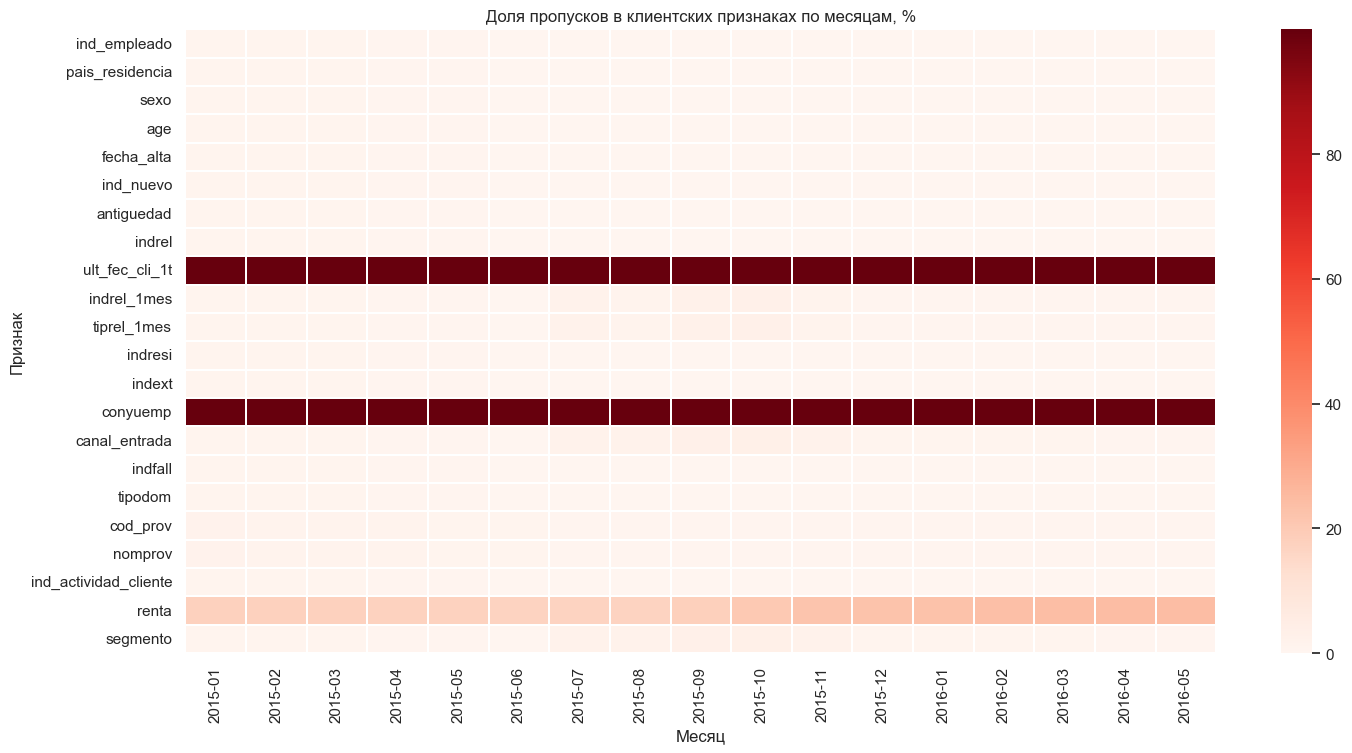

In [25]:
PROFILE_SOURCE_COLUMNS = [
    column for column in source_column_order
    if column not in PRODUCT_COLUMNS and column not in {ID_COLUMN, DATE_COLUMN}
]
monthly_sizes = snapshots.groupby(DATE_COLUMN, observed=True).size()
monthly_non_null = snapshots.groupby(
    DATE_COLUMN,
    observed=True,
)[PROFILE_SOURCE_COLUMNS].count()
monthly_missing_rate = (
    1 - monthly_non_null.div(monthly_sizes, axis=0)
).T
monthly_missing_rate = monthly_missing_rate.loc[
    monthly_missing_rate.max(axis=1).gt(0)
]
monthly_missing_rate.columns = [
    date.strftime("%Y-%m") for date in monthly_missing_rate.columns
]

plt.figure(figsize=(15, max(6, 0.35 * len(monthly_missing_rate))))
sns.heatmap(
    100 * monthly_missing_rate,
    cmap="Reds",
    linewidths=0.2,
)
plt.title("Доля пропусков в клиентских признаках по месяцам, %")
plt.xlabel("Месяц")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()


## 12. Главные выводы

1. В файле 13 647 309 строк, 956 645 клиентов и 17 месяцев. Дубликатов `клиент–месяц` нет. У 605 464 клиентов есть все 17 снимков, а у 8 018 внутри истории пропущен хотя бы один месяц. Самый большой рост произошёл в июле 2015 года: строк стало на 31.3% больше, чем в июне.
2. Проверены все 48 колонок. `ult_fec_cli_1t` пусто в 99.82% строк, `conyuemp` — в 99.99%, а у `tipodom` есть только одно непустое значение. В нынешнем виде эти поля дают мало информации. Ещё у 11 586 строк `fecha_alta` оказалась позже даты снимка.
3. В последних профилях клиентов есть 7 490 возрастов младше 18 лет и 992 старше 100 лет. У стажа найдено три отрицательных значения, включая `-999999`. У дохода 20.48% пропусков, а максимум достигает 28.9 млн. Возраст и стаж нужно очищать, доход — логарифмировать, а правила обработки считать только на обучающих данных.
4. Значения вроде `1` и `1.0` в `indrel_1mes` приведены к одному виду. `cod_prov` тоже переведён в строковый формат и согласуется с `nomprov`. В `canal_entrada` найдено 162 значения, причём 125 из них встречаются реже чем в 0.1% последних профилей. Модель должна спокойно работать с такими редкими категориями.
5. В последнем месяце у 25.22% клиентов нет ни одного продукта, а у 48.63% есть ровно один. Текущий счёт есть у 60.29% клиентов, а банковская гарантия — только у 16. Поэтому продукты важно рассматривать по отдельности.
6. Получилось 12 669 584 пар соседних месяцев, где известны все продуктовые флаги. В них найдено 561 648 подключений `0→1`, но хотя бы одна покупка есть только в 3.52% пар. Чаще всего подключалось прямое дебетование: 153 146 событий среди пар, подходящих для этого продукта. В тех же условиях найдено 533 164 отключения `1→0`.
7. В проверочном периоде апрель→май у трёх продуктов нет ни одной покупки, а у сберегательного счёта она всего одна. Поэтому общей MAP@7 недостаточно: качество нужно смотреть и по отдельным продуктам.
8. Активные клиенты заметно чаще подключают новые продукты: 68.54 случая на 1000 пар против 6.73 у неактивных. Для сегмента TOP показатель равен 97.11, а для университетского сегмента — 16.74. Эти различия полезны для модели, но проверять их нужно на следующем месяце, а не на случайной выборке строк.
9. Пропуск продуктового флага не означает, что продукта нет. Такие состояния исключаются из переходов, а модель обучается только на соседних месяцах со всеми известными флагами. Для оценки используем временную проверку, MAP@7, Recall@7 и Precision@7. Обычная accuracy здесь почти ничего не говорит.
